#### Libraries

In [1]:
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import numpy as np

#### Linking Functions notebook

In [4]:
# Adding path to system
import sys
sys.path.append(r"C:\\Users\\eliya\\Documents\\עבודה\\עוזר מחקר\\4. פרויקטים\\1. quality measures\\1. Feature Completeness")

In [58]:
# Importing relevant functions
import importlib
import functions
importlib.reload(functions)
from functions import get_len, get_count, get_add_from_cum

[NbConvertApp] Converting notebook C:/Users/eliya/Documents/עבודה/עוזר מחקר/4. פרויקטים/1. quality measures/1. Feature Completeness/functions.ipynb to script
[NbConvertApp] Writing 7912 bytes to C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\functions.py


## Counting ways

URL for extracting bounding box:
https://boundingbox.klokantech.com/

### Heidelberg area

In [1]:
heid_bbox = "8.1543,49.1757,9.1351,49.6884"

In [126]:
# Extracting counts and length - 3 month interval
heidelberg_counts = get_count(heid_bbox, time="2008-01-01/2025-01-01/P1M")
heidelberg_len = get_len(heid_bbox, time="2008-01-01/2025-01-01/P1M")

Succesfully extracted counts
Succesfully extracted lengths


In [81]:
# Extracting added values from cummulative values
heidelberg_counts = get_add_from_cum(heidelberg_counts)
heidelberg_len = get_add_from_cum(heidelberg_len)

In [9]:
# Fixing timestamp
heidelberg_counts['timestamp'] = pd.to_datetime(heidelberg_counts['timestamp'])
heidelberg_len['timestamp'] = pd.to_datetime(heidelberg_len['timestamp'])

In [164]:
def semi_norm_mix_transform(count_gdf, size_gdf, value_column='value', alpha=0.3, time_thresh=2):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative length of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added lengths per each added unit.
    After that, the function applies the following statistical test:
        If all cumulative change percentage is below 3% for given previous years (default value - 2), the data is considered saturated, and then the umulatitve percentage of data is calculated up to that point.

    The output is a DataFrame with cumulative percentages and all calculated values for saturated data and the first timestamp where the data is 80% saturated.
    '''
    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Transform values
    count_gdf['cumulative_percentage'] = size_gdf[value_column] / count_gdf[value_column]
    count_gdf['normalized_cum_per'] = count_gdf['cumulative_percentage'] / count_gdf['cumulative_percentage'].max()

    # Extract inputs from ime threshold onwards
    cutoff = count_gdf['timestamp'].max() - pd.DateOffset(years=time_thresh)
    thresh = count_gdf[count_gdf['timestamp'] >= cutoff].copy()

    # Apply completeness test for level alpha
    thresh['test'] = (thresh['normalized_cum_per'] < alpha).astype(int)

    ## If any row fails test, data is considered incomplete
    if any(thresh['test'] == 0):
        print('Data incomplete')
        return count_gdf
    
    ## For data considered full in polygon
    else:
        # Reshape output values
        count_gdf['cumulative_length'] = size_gdf[value_column] # Append size column
        count_gdf = count_gdf[['timestamp', value_column, 'cumulative_length', 'cumulative_percentage', 'normalized_cum_per']]
        
        # Extract max values
        saturated = thresh.iloc[0].drop('test') # Defined saturated value
        real_max = count_gdf.iloc[-1] # Emprical maximal value
        
        # Filter data until saturation
        count_gdf = count_gdf[count_gdf['timestamp'] < saturated['timestamp']].copy()

        # Concatenating maximal values (saturation, empirical)
        output = pd.concat([count_gdf, 
                   pd.DataFrame([saturated]), 
                   pd.DataFrame([real_max])], 
                  ignore_index=True)
        
        # Calculating saturation levels
        output['percentage_until_saturation'] = output[value_column] / saturated[value_column]
        output = output.rename(columns={value_column : 'cumulative_count'}) # Rename count column (after operation for corect ambiguity)


        # Extracting 80% saturation timestamp
        saturated_time = output[output['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]
        print(f'Polygon 80% saturated at {saturated_time}')

        return output


In [165]:
test = semi_norm_mix_transform(heidelberg_counts, heidelberg_len, alpha=0.30)

Polygon 80% saturated at 2018-08-01 00:00:00+00:00


In [167]:
test.tail(n=10)

,timestamp,cumulative_count,cumulative_length,cumulative_percentage,normalized_cum_per,percentage_until_saturation
172,2022-05-01 00:00:00+00:00,297695.0,46717906.65,156.932117,0.299441,0.979759
173,2022-06-01 00:00:00+00:00,298653.0,46770262.01,156.604025,0.298815,0.982912
174,2022-07-01 00:00:00+00:00,299149.0,46802810.81,156.453175,0.298527,0.984545
175,2022-08-01 00:00:00+00:00,299882.0,46844816.01,156.210830,0.298064,0.986957
176,2022-09-01 00:00:00+00:00,300442.0,46878188.35,156.030743,0.297721,0.988800
177,2022-10-01 00:00:00+00:00,301282.0,46939312.95,155.798597,0.297278,0.991565
178,2022-11-01 00:00:00+00:00,302120.0,46976326.36,155.488966,0.296687,0.994323
179,2022-12-01 00:00:00+00:00,303112.0,47011443.19,155.095949,0.295937,0.997588
180,2023-01-01 00:00:00+00:00,303845.0,NaN,154.827225,0.295424,1.000000
181,2025-01-01 00:00:00+00:00,326058.0,47997699.28,147.206016,0.280882,1.073106


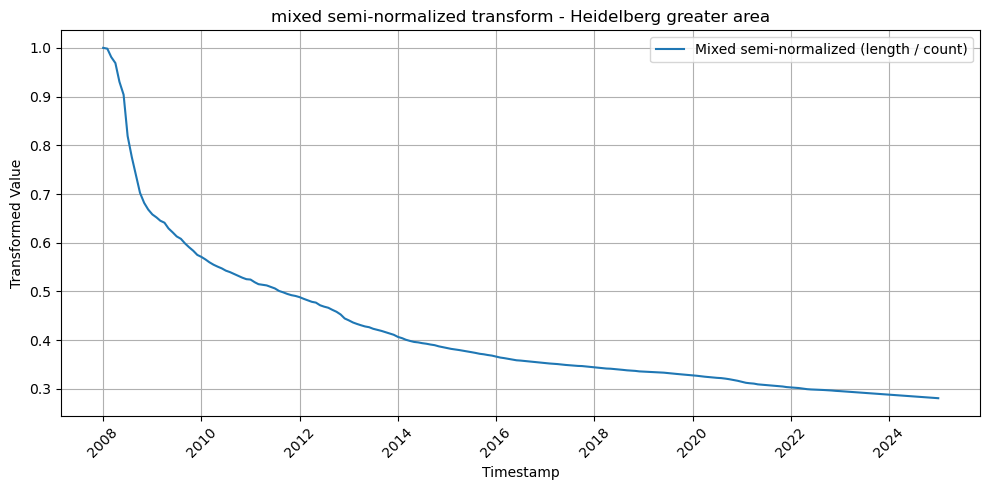

In [128]:
plt.figure(figsize=(10, 5))
plt.plot(test['timestamp'], test['normalized_cum_per'], linestyle='-', label='Mixed semi-normalized (length / count)')
plt.xlabel('Timestamp')
plt.ylabel('Transformed Value')
plt.title('mixed semi-normalized transform - Heidelberg greater area')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Adding value transformations
## Log transformations
heidelberg_counts['log_add'] = np.log(heidelberg_counts['added_value']) # added value - counts
heidelberg_counts['log_cum'] = np.log(heidelberg_counts['cummulative_value']) # cummulative value - counts
heidelberg_len['log_add'] = np.log(heidelberg_len['added_value']) # added value - length
heidelberg_len['log_cum'] = np.log(heidelberg_len['cummulative_value']) # cummulative value - length

## Normalize transformation
heidelberg_counts['norm_add'] = (heidelberg_counts['added_value'] - heidelberg_counts['added_value'].mean()) / heidelberg_counts['added_value'].std() # added value - counts
heidelberg_counts['norm_cum'] = (heidelberg_counts['cummulative_value'] - heidelberg_counts['cummulative_value'].mean()) / heidelberg_counts['cummulative_value'].std() # cummulative value - counts
heidelberg_len['norm_add'] = (heidelberg_len['added_value'] - heidelberg_len['added_value'].mean()) / heidelberg_len['added_value'].std() # added value - length
heidelberg_len['norm_cum'] = (heidelberg_len['cummulative_value'] - heidelberg_len['cummulative_value'].mean()) / heidelberg_len['cummulative_value'].std() # cummulative value - length

## Moving average transformation
heidelberg_counts['moving_avg_cum_50'] = heidelberg_counts['cummulative_value'].rolling(window=50).mean()
heidelberg_counts['moving_avg_add_50'] = heidelberg_counts['added_value'].rolling(window=50).mean()
heidelberg_counts['moving_avg_cum_30'] = heidelberg_counts['cummulative_value'].rolling(window=30).mean()
heidelberg_counts['moving_avg_add_30'] = heidelberg_counts['added_value'].rolling(window=30).mean()
heidelberg_counts['moving_avg_cum_10'] = heidelberg_counts['cummulative_value'].rolling(window=10).mean()
heidelberg_counts['moving_avg_add_10'] = heidelberg_counts['added_value'].rolling(window=10).mean()
heidelberg_counts['moving_avg_cum_5'] = heidelberg_counts['cummulative_value'].rolling(window=5).mean()
heidelberg_counts['moving_avg_add_5'] = heidelberg_counts['added_value'].rolling(window=5).mean()

## Semi-normalize: normalize lengths to counts
heidelberg_counts['semi_norm'] = heidelberg_counts['added_value'] / heidelberg_counts['cummulative_value']
# heidelberg_len['semi_norm'] = heidelberg_counts['added_value'] / heidelberg_counts['cummulative_value']
heidelberg_counts['semi_norm_mixed'] = heidelberg_len['cummulative_value'] / heidelberg_counts['cummulative_value']
# heidelberg_counts['semi_norm_mixed_inverce'] = heidelberg_counts['added_value'] / heidelberg_len['added_value']
heidelberg_counts['semi_norm_mixed'] = heidelberg_counts['semi_norm_mixed'] / heidelberg_counts['semi_norm_mixed'].max()

## Gompertz curve

## Sigmoid function

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [84]:
heidelberg_counts['semi_norm_mixed'] = heidelberg_len['cummulative_value'] / heidelberg_counts['cummulative_value']

heidelberg_counts['semi_norm_mixed'] = heidelberg_counts['semi_norm_mixed'] / heidelberg_counts['semi_norm_mixed'].max()


In [105]:
heidelberg_counts[['timestamp', 'added_value', 'cummulative_value', 'semi_norm', 'semi_norm_mixed']]

,timestamp,added_value,cummulative_value,semi_norm,semi_norm_mixed
0,2008-01-01 00:00:00+00:00,9651.0,9651.0,1.000000,524.084141
1,2008-02-01 00:00:00+00:00,549.0,10200.0,0.053824,2662.146485
2,2008-03-01 00:00:00+00:00,1269.0,11469.0,0.110646,2656.582072
3,2008-04-01 00:00:00+00:00,1372.0,12841.0,0.106845,2735.565488
4,2008-05-01 00:00:00+00:00,1862.0,14703.0,0.126641,1200.620918
...,...,...,...,...,...
200,2024-09-01 00:00:00+00:00,755.0,322111.0,0.002344,NaN
201,2024-10-01 00:00:00+00:00,1281.0,323392.0,0.003961,NaN
202,2024-11-01 00:00:00+00:00,863.0,324255.0,0.002661,NaN
203,2024-12-01 00:00:00+00:00,751.0,325006.0,0.002311,NaN


In [106]:
heidelberg_len[['timestamp', 'added_value', 'cummulative_value', 'semi_norm']]

,timestamp,added_value,cummulative_value,semi_norm
0,2008-01-01 00:00:00+00:00,5057936.04,5057936.04,1.000000
1,2008-04-01 00:00:00+00:00,1461518.42,6519454.46,0.053824
2,2008-07-01 00:00:00+00:00,3371202.65,9890657.11,0.110646
3,2008-10-01 00:00:00+00:00,3753195.85,13643852.96,0.106845
4,2009-01-01 00:00:00+00:00,2235556.15,15879409.11,0.126641
...,...,...,...,...
64,2024-01-01 00:00:00+00:00,94112.72,47571375.02,0.012367
65,2024-04-01 00:00:00+00:00,94641.97,47666016.99,0.012087
66,2024-07-01 00:00:00+00:00,137585.82,47803602.81,0.015138
67,2024-10-01 00:00:00+00:00,101752.25,47905355.06,0.008492


In [ ]:
heidelberg_counts['semi_norm_mixed_inverce'] = heidelberg_counts['added_value'] / heidelberg_len['added_value']

In [ ]:
## Amplitude estimation
import numpy as np
from scipy.signal import find_peaks

peaks, _ = find_peaks(heidelberg_counts['added_value'])
troughs, _ = find_peaks(-heidelberg_counts['added_value'])

extrema_indices = np.sort(np.concatenate((peaks, troughs)))
mid_indices = (extrema_indices[:-1] + extrema_indices[1:]) / 2
extrema_timestamps = heidelberg_counts.loc[extrema_indices, 'timestamp']
mid_timestamps = extrema_timestamps[:-1] + (extrema_timestamps[1:].values - extrema_timestamps[:-1].values)/2


extrema_values = heidelberg_counts.loc[extrema_indices, 'added_value'].values
abs_differences = np.abs(extrema_values[1:] - extrema_values[:-1])


df_diff_add = pd.DataFrame({
    'timestamp': mid_timestamps,
    'abs_difference': abs_differences
})

peaks, _ = find_peaks(heidelberg_counts['cummulative_value'])
troughs, _ = find_peaks(-heidelberg_counts['cummulative_value'])

extrema_indices = np.sort(np.concatenate((peaks, troughs)))
mid_indices = (extrema_indices[:-1] + extrema_indices[1:]) / 2
extrema_timestamps = heidelberg_counts.loc[extrema_indices, 'timestamp']
mid_timestamps = extrema_timestamps[:-1] + (extrema_timestamps[1:].values - extrema_timestamps[:-1].values)/2


extrema_values = heidelberg_counts.loc[extrema_indices, 'cummulative_value'].values
abs_differences = np.abs(extrema_values[1:] - extrema_values[:-1])


df_diff_cum = pd.DataFrame({
    'timestamp': mid_timestamps,
    'abs_difference': abs_differences
})

In [84]:
heidelberg_counts

,timestamp,cummulative_value,added_value,log_add,log_cum,norm_add,norm_cum,moving_avg_cum_50,moving_avg_add_50,moving_avg_cum_30,moving_avg_add_30,moving_avg_cum_10,moving_avg_add_10,moving_avg_cum_5,moving_avg_add_5,semi_norm,semi_norm_mixed
0,2008-01-01 00:00:00+00:00,9651.0,9651.0,9.174817,9.174817,7.494593,-2.231588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,524.084141
1,2008-02-01 00:00:00+00:00,10200.0,549.0,6.308098,9.230143,-0.968407,-2.225234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.053824,2662.146485
2,2008-03-01 00:00:00+00:00,11469.0,1269.0,7.145984,9.347403,-0.298954,-2.210548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.110646,2656.582072
3,2008-04-01 00:00:00+00:00,12841.0,1372.0,7.224025,9.460398,-0.203185,-2.194670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106845,2735.565488
4,2008-05-01 00:00:00+00:00,14703.0,1862.0,7.529406,9.595807,0.252415,-2.173122,NaN,NaN,NaN,NaN,NaN,NaN,11772.8,2940.6,0.126641,1200.620918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,2024-09-01 00:00:00+00:00,322111.0,755.0,6.626718,12.682651,-0.776869,1.384476,297915.40,1137.70,308303.433333,910.633333,316919.8,1062.4,319636.4,1284.6,0.002344,NaN
201,2024-10-01 00:00:00+00:00,323392.0,1281.0,7.155396,12.686620,-0.287797,1.399301,299060.36,1144.96,309205.666667,902.233333,318018.9,1099.1,320978.6,1342.2,0.003961,NaN
202,2024-11-01 00:00:00+00:00,324255.0,863.0,6.760415,12.689286,-0.676451,1.409289,300189.18,1128.82,310091.000000,885.333333,319121.2,1102.3,322226.4,1247.8,0.002661,NaN
203,2024-12-01 00:00:00+00:00,325006.0,751.0,6.621406,12.691599,-0.780588,1.417980,301300.40,1111.22,310969.433333,878.433333,320183.8,1062.6,323224.0,997.6,0.002311,NaN


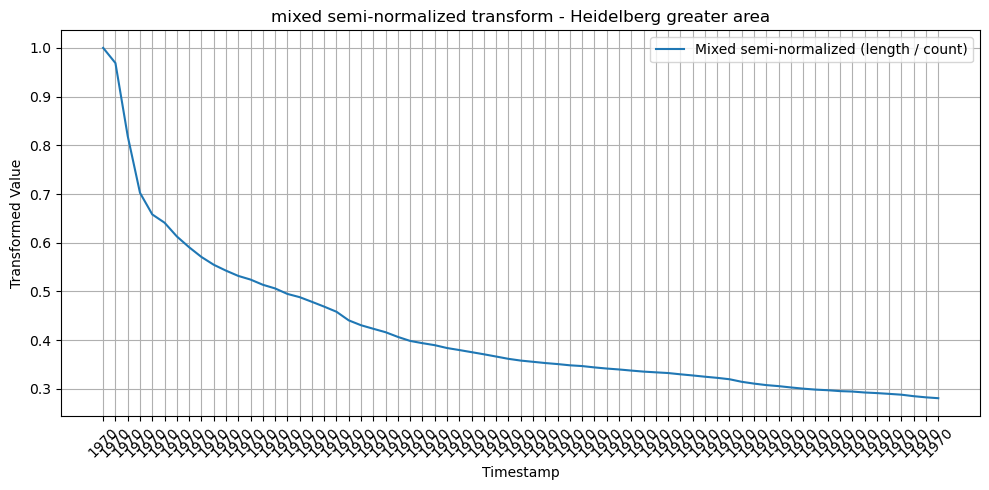

In [85]:
# Plotting data
plt.figure(figsize=(10, 5))

# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['cummulative_value'], linestyle='-', label='Cummulative Road Counts')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['added_value'], linestyle='-', label='Added Road Counts')

# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['log_cum'], linestyle='-', label='Cummulative Road Length (log)')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['log_add'], linestyle='-', label='Added Road Length (log)')

# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['semi_norm'], linestyle='-', label='Semi-normalized (added / cummulative)')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['semi_norm_mixed'], linestyle='-', label='Mixed semi-normalized (length / count)')
plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['semi_norm_mixed'], linestyle='-', label='Mixed semi-normalized (length / count)')


# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['cummulative_value'], linestyle='-', label='Cummulative Road Counts')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['added_value'], linestyle='-', label='Added Road Counts')

# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_cum_50'], linestyle='-', label='Moving Average Model (window = 50)')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_add_50'], linestyle='-', label='Moving Average Model (window = 50)')

# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_cum_30'], linestyle='-', label='Moving Average Model (window = 30)')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_add_30'], linestyle='-', label='Moving Average Model (window = 30)')

# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_cum_10'], linestyle='-', label='Moving Average Model (window = 10)')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_add_10'], linestyle='-', label='Moving Average Model (window = 10)')

# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_cum_5'], linestyle='-', label='Moving Average Model (window = 5)')
# plt.plot(heidelberg_counts['timestamp'], heidelberg_counts['moving_avg_add_5'], linestyle='-', label='Moving Average Model (window = 5)')

plt.xlabel('Timestamp')
# plt.ylabel('Cumulative Value (log scaled)')
plt.ylabel('Transformed Value')
plt.title('mixed semi-normalized transform - Heidelberg greater area')
# plt.title('Cumulative Plot over Time - Heidelberg greater area')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Paris

In [116]:
par_bbox = "2.255031,48.813564,2.426418,48.904637" # bounding box coordinates

# Extracting counts and length - 3 month interval
paris_c = get_count(par_bbox)
paris_l = get_len(par_bbox)

# Fixing timestamp
paris_c['timestamp'] = pd.to_datetime(paris_c['timestamp'])
paris_l['timestamp'] = pd.to_datetime(paris_l['timestamp'])

# Adding value transformations
paris_c['log_val'] = np.log(paris_c['value']) # log transformation
paris_l['log_val'] = np.log(paris_l['value']) # log transformation

Succesfully extracted counts
Succesfully extracted lengths


In [117]:
paris_c = get_add_from_cum(paris_c)
paris_l = get_add_from_cum(paris_l)


In [129]:
paris_c['val'] = paris_l['cummulative_value'] / paris_c['cummulative_value']

#paris_c['semi_norm_mixed'] = paris_c['semi_norm_mixed'] / paris_c['semi_norm_mixed'].max()

In [121]:
paris_c['semi_norm'] = paris_c['added_value'] / paris_c['cummulative_value']


In [128]:
paris_l.tail()

,timestamp,cummulative_value,log_val,added_value
64,2024-01-01 00:00:00+00:00,6356510.72,15.664990,58207.69
65,2024-04-01 00:00:00+00:00,6454356.56,15.680266,97845.84
66,2024-07-01 00:00:00+00:00,6537499.19,15.693065,83142.63
67,2024-10-01 00:00:00+00:00,6594031.80,15.701676,56532.61
68,2025-01-01 00:00:00+00:00,6677385.79,15.714237,83353.99


In [130]:
paris_c.tail()

,timestamp,cummulative_value,log_val,added_value,semi_norm_mixed,semi_norm,val
200,2024-09-01 00:00:00+00:00,137208.0,11.829253,550.0,NaN,0.004009,NaN
201,2024-10-01 00:00:00+00:00,138417.0,11.838026,1209.0,NaN,0.008734,NaN
202,2024-11-01 00:00:00+00:00,141327.0,11.858832,2910.0,NaN,0.020591,NaN
203,2024-12-01 00:00:00+00:00,142869.0,11.869683,1542.0,NaN,0.010793,NaN
204,2025-01-01 00:00:00+00:00,143318.0,11.872821,449.0,NaN,0.003133,NaN


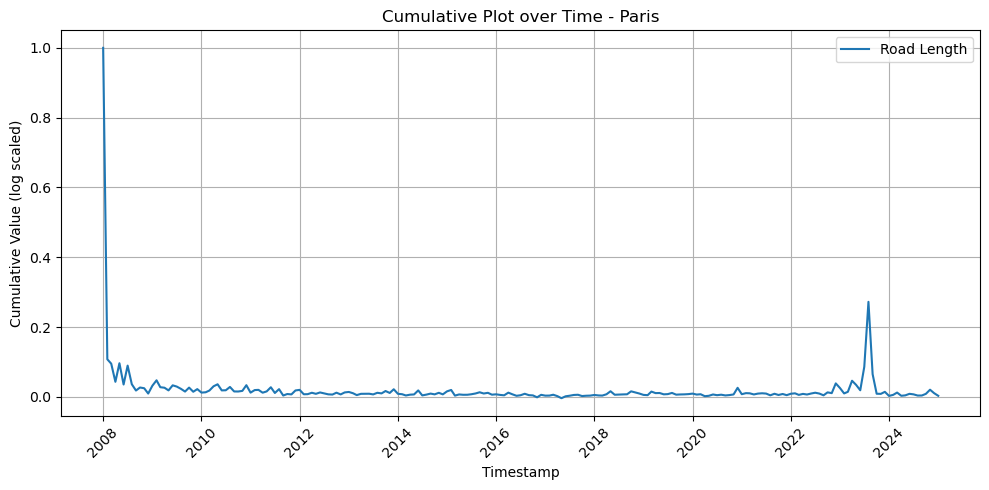

In [ ]:
# Plotting data
plt.figure(figsize=(10, 5))
#plt.plot(paris_c['timestamp'], paris_c['value'], linestyle='-', label='Road Counts')
#plt.plot(paris_l['timestamp'], paris_l['value'], linestyle='-', label='Road Length')
plt.plot(paris_c['timestamp'], paris_c['semi_norm_mi'], linestyle='-', label='Road Length')


plt.xlabel('Timestamp')
plt.ylabel('Cumulative Value (log scaled)')
plt.title('Cumulative Plot over Time - Paris')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hainan

In [ ]:
hai_bbox = "108.4078,18.0357,111.1148,20.1493" # bounding box coordinates

# Extracting counts and length - 3 month interval
hainan_c = get_count(hai_bbox)
hainan_l = get_len(hai_bbox)

# Fixing timestamp
hainan_c['timestamp'] = pd.to_datetime(hainan_c['timestamp'])
hainan_l['timestamp'] = pd.to_datetime(hainan_l['timestamp'])

# Adding value transformations
hainan_c['log_val'] = np.log(hainan_c['value']) # log transformation
hainan_l['log_val'] = np.log(hainan_l['value']) # log transformation
hainan_c['sqr_val'] = np.square(hainan_c['value']) # square transformation
hainan_l['sqr_val'] = np.square(hainan_l['value']) # square transformation

In [ ]:
# Plotting data
plt.figure(figsize=(10, 5))
plt.plot(hainan_c['timestamp'], hainan_c['log_val'], linestyle='-', label='Road Counts')
plt.plot(hainan_l['timestamp'], hainan_l['log_val'], linestyle='-', label='Road Length')

plt.xlabel('Timestamp')
plt.ylabel('Cumulative Value (log scaled)')
plt.title('Cumulative Plot over Time - Hainan')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Thailand

In [ ]:
thai_isl_bbox = "99.6253,9.3452,100.201,10.1602" # bounding box coordinates

# Extracting counts and length - 3 month interval
kohs_c = get_count(thai_isl_bbox)
kohs_l = get_len(thai_isl_bbox)

# Fixing timestamp
kohs_c['timestamp'] = pd.to_datetime(kohs_c['timestamp'])
kohs_l['timestamp'] = pd.to_datetime(kohs_l['timestamp'])

# Adding value transformations
kohs_c['log_val'] = np.log(kohs_c['value']) # log transformation
kohs_l['log_val'] = np.log(kohs_l['value']) # log transformation

In [ ]:
# Plotting data
plt.figure(figsize=(10, 5))
plt.plot(kohs_c['timestamp'], kohs_c['log_val'], linestyle='-', label='Road Counts')
plt.plot(kohs_l['timestamp'], kohs_l['log_val'], linestyle='-', label='Road Length')

plt.xlabel('Timestamp')
plt.ylabel('Cumulative Value (log scaled)')
plt.title('Cumulative Plot over Time - Thailand South Islands')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Israel

In [ ]:
bshemesh_bbox = "34.938188,31.689471,35.035005,31.786876" # bounding box coordinates

# Extracting counts and length - 3 month interval
bsh_c = get_count(bshemesh_bbox)
bsh_l = get_len(bshemesh_bbox)

# Fixing timestamp
bsh_c['timestamp'] = pd.to_datetime(bsh_c['timestamp'])
bsh_l['timestamp'] = pd.to_datetime(bsh_l['timestamp'])

# Adding value transformations
bsh_c['log_val'] = np.log(bsh_c['value']) # log transformation
bsh_l['log_val'] = np.log(bsh_l['value']) # log transformation

In [ ]:
# Plotting data
plt.figure(figsize=(10, 5))
plt.plot(bsh_c['timestamp'], bsh_c['log_val'], linestyle='-', label='Road Counts')
plt.plot(bsh_l['timestamp'], bsh_l['log_val'], linestyle='-', label='Road Length')

plt.xlabel('Timestamp')
plt.ylabel('Cumulative Value (log scaled)')
plt.title('Cumulative Plot over Time - Thailand South Islands')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Extracting measure

In [7]:
b_boxes = gpd.read_file("C:/Users/eliya/Documents/עבודה/עוזר מחקר/Data/Large-scale events/event_weights_grid.shp")

In [ ]:
# Applying event names
b_boxes = b_boxes.rename(columns={
    'events_w_1' : 'local_knowledge',
    'events_w_2' : 'tag_import',
    'events_w_3' : 'remote_event',
    'events_w_4' : 'late_import',
    'events_w_5' : 'geometry_import',
    'events_w_6' : 'weight_sum',
    'events_wei' : 'early_import'
})

In [99]:
# Extracting bounding box coordinates
b_boxes[['minx', 'miny', 'maxx', 'maxy']] = b_boxes.bounds
b_boxes['bbox'] = b_boxes.apply(
    lambda row: f"{row['minx']},{row['miny']},{row['maxx']},{row['maxy']}",
    axis=1
)

In [100]:
# Splitting into different event types
local_knowledge_event = b_boxes[b_boxes['local_knowledge'] != 0][['id', 'entities', 'local_knowledge', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
remote_event = b_boxes[b_boxes['remote_event'] != 0][['id', 'entities', 'remote_event', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
early_import = b_boxes[b_boxes['early_import'] != 0][['id', 'entities', 'early_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
geometry_import = b_boxes[b_boxes['geometry_import'] != 0][['id', 'entities', 'geometry_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
tag_import = b_boxes[b_boxes['tag_import'] != 0][['id', 'entities', 'tag_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
late_import = b_boxes[b_boxes['late_import'] != 0][['id', 'entities', 'late_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]

In [101]:
# Sampling areas with significant percentage of event type for analysis
local_knowledge_samp = local_knowledge_event[local_knowledge_event['local_knowledge'] > 60]
remote_event_samp = remote_event[remote_event['remote_event'] > 80]
early_import_samp = early_import[early_import['early_import'] > 80]
geometry_import_samp = geometry_import[geometry_import['geometry_import'] > 50]
tag_import_samp = tag_import[tag_import['tag_import'] > 45]
late_import_samp = late_import[late_import['late_import'] > 60]


# Printing sample sizes
print('Number of sampled areas (n):')
print(f'   Local knowledge: {local_knowledge_samp.shape[0]}')
print(f'   Remote event: {remote_event_samp.shape[0]}')
print(f'   Early imports: {early_import_samp.shape[0]}')
print(f'   Geometry imports: {geometry_import_samp.shape[0]}')
print(f'   Tag imports: {tag_import_samp.shape[0]}')
print(f'   Late imports: {late_import_samp.shape[0]}')
print(f'\nTotal sample size: n = {local_knowledge_samp.shape[0] +
                                      remote_event_samp.shape[0] +
                                      early_import_samp.shape[0] +
                                      geometry_import_samp.shape[0] +
                                      tag_import_samp.shape[0] +
                                      late_import_samp.shape[0]}')

Number of sampled areas (n):
   Local knowledge: 28
   Remote event: 259
   Early imports: 127
   Geometry imports: 8
   Tag imports: 9
   Late imports: 15

Total sample size: n = 446


In [102]:
local_knowledge_samp

,id,entities,local_knowledge,geometry,minx,miny,maxx,maxy,bbox
1775,1776,58955.0,63.997417,"POLYGON ((-72.773 18.984, -72.773 19.16, -72.4...",-72.773438,18.984375,-72.421875,19.160156,"-72.7734375,18.984375,-72.421875,19.16015625"
1782,1783,30749.0,67.598822,"POLYGON ((-72.422 19.688, -72.422 20.039, -71....",-72.421875,19.687500,-71.718750,20.039062,"-72.421875,19.6875,-71.71875,20.0390625"
3599,3600,35640.0,68.649403,"POLYGON ((32.344 -25.84, 32.344 -25.664, 32.69...",32.343750,-25.839844,32.695312,-25.664062,"32.34375,-25.83984375,32.6953125,-25.6640625"
3716,3717,92456.0,66.094857,"POLYGON ((27.422 -16.523, 27.422 -16.172, 28.1...",27.421875,-16.523438,28.125000,-16.171875,"27.421875,-16.5234375,28.125,-16.171875"
3757,3758,38645.0,66.532091,"POLYGON ((34.453 -19.688, 34.453 -19.336, 35.1...",34.453125,-19.687500,35.156250,-19.335938,"34.453125,-19.6875,35.15625,-19.3359375"
3758,3759,30021.0,64.310453,"POLYGON ((33.75 -18.984, 33.75 -18.633, 34.453...",33.750000,-18.984375,34.453125,-18.632812,"33.75,-18.984375,34.453125,-18.6328125"
3893,3894,34793.0,71.531864,"POLYGON ((30.234 -1.7578, 30.234 -1.4062, 30.9...",30.234375,-1.757812,30.937500,-1.406250,"30.234375,-1.7578125,30.9375,-1.40625"
3900,3901,24578.0,83.867608,"POLYGON ((30.059 -1.4062, 30.059 -1.3184, 30.2...",30.058594,-1.406250,30.234375,-1.318359,"30.05859375,-1.40625,30.234375,-1.318359375"
3901,3902,64307.0,66.725632,"POLYGON ((29.883 -1.2305, 29.883 -1.0547, 30.2...",29.882812,-1.230469,30.234375,-1.054688,"29.8828125,-1.23046875,30.234375,-1.0546875"
3966,3967,168450.0,71.024336,"POLYGON ((39.199 -6.8555, 39.199 -6.8115, 39.2...",39.199219,-6.855469,39.287109,-6.811523,"39.19921875,-6.85546875,39.287109375,-6.811523..."
